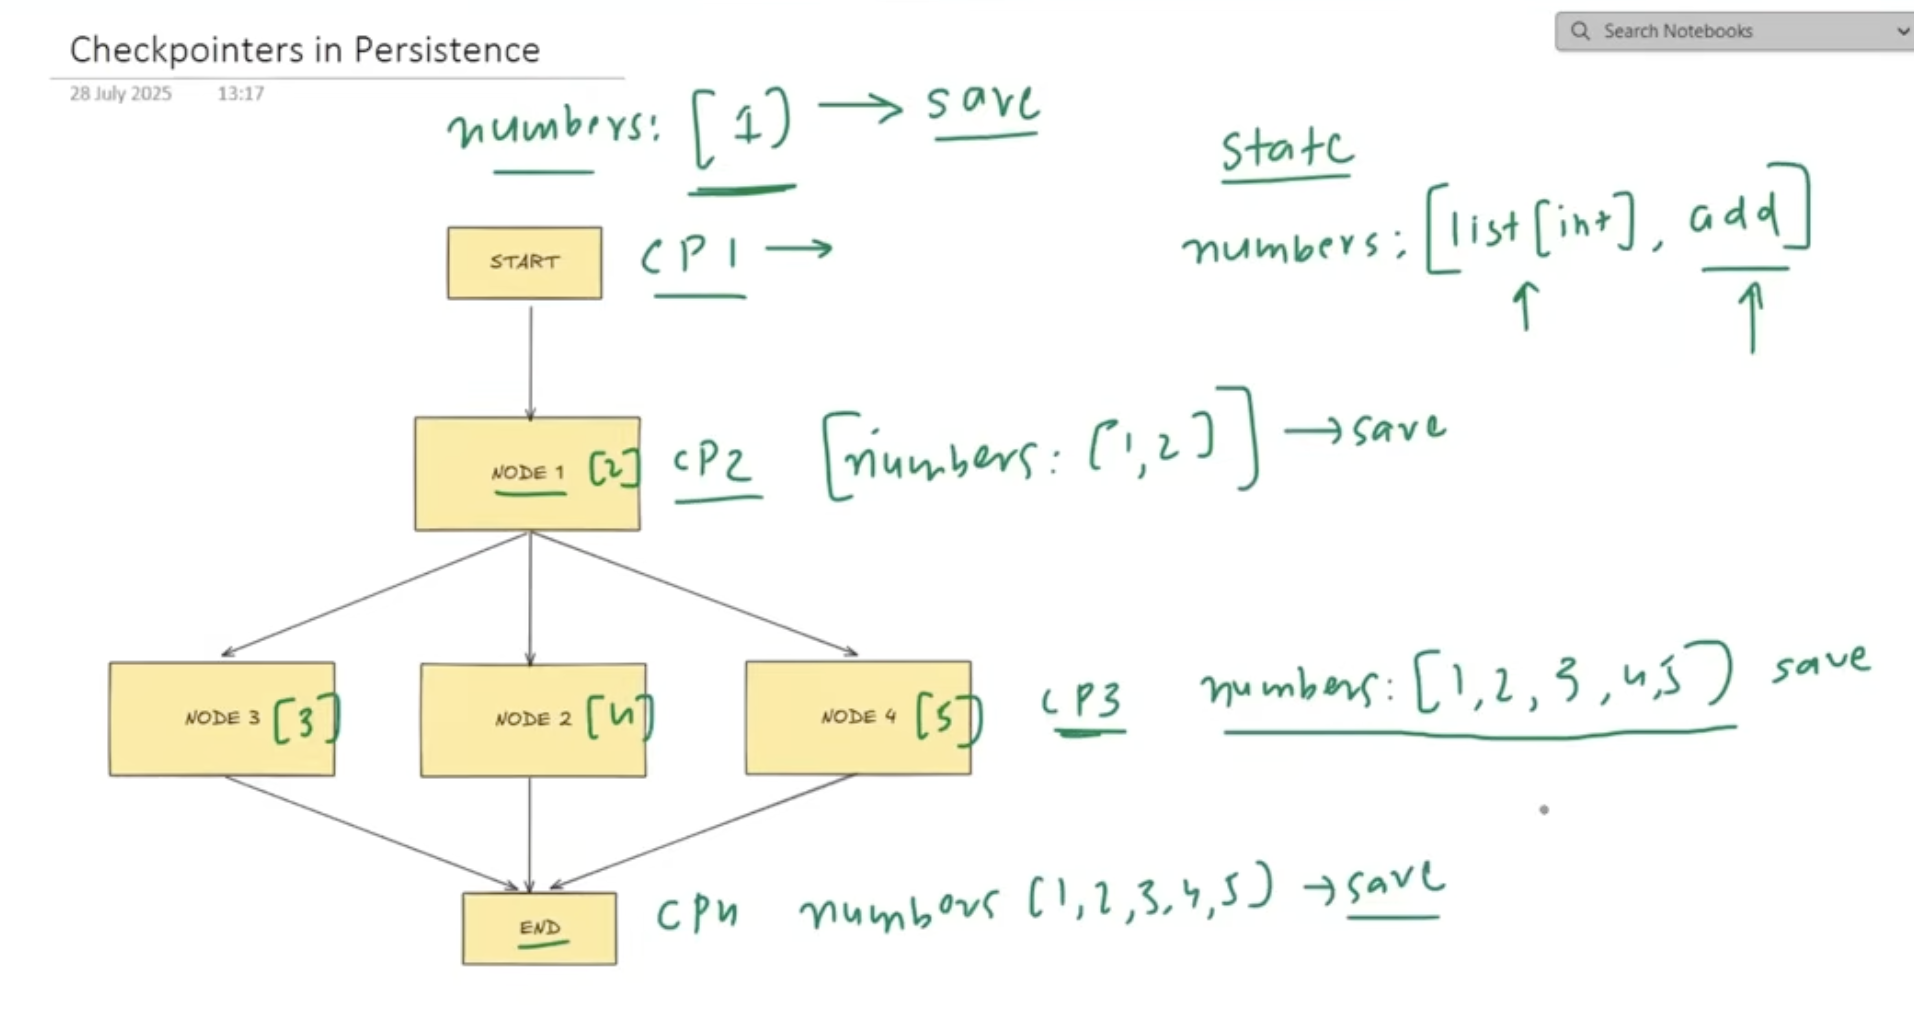

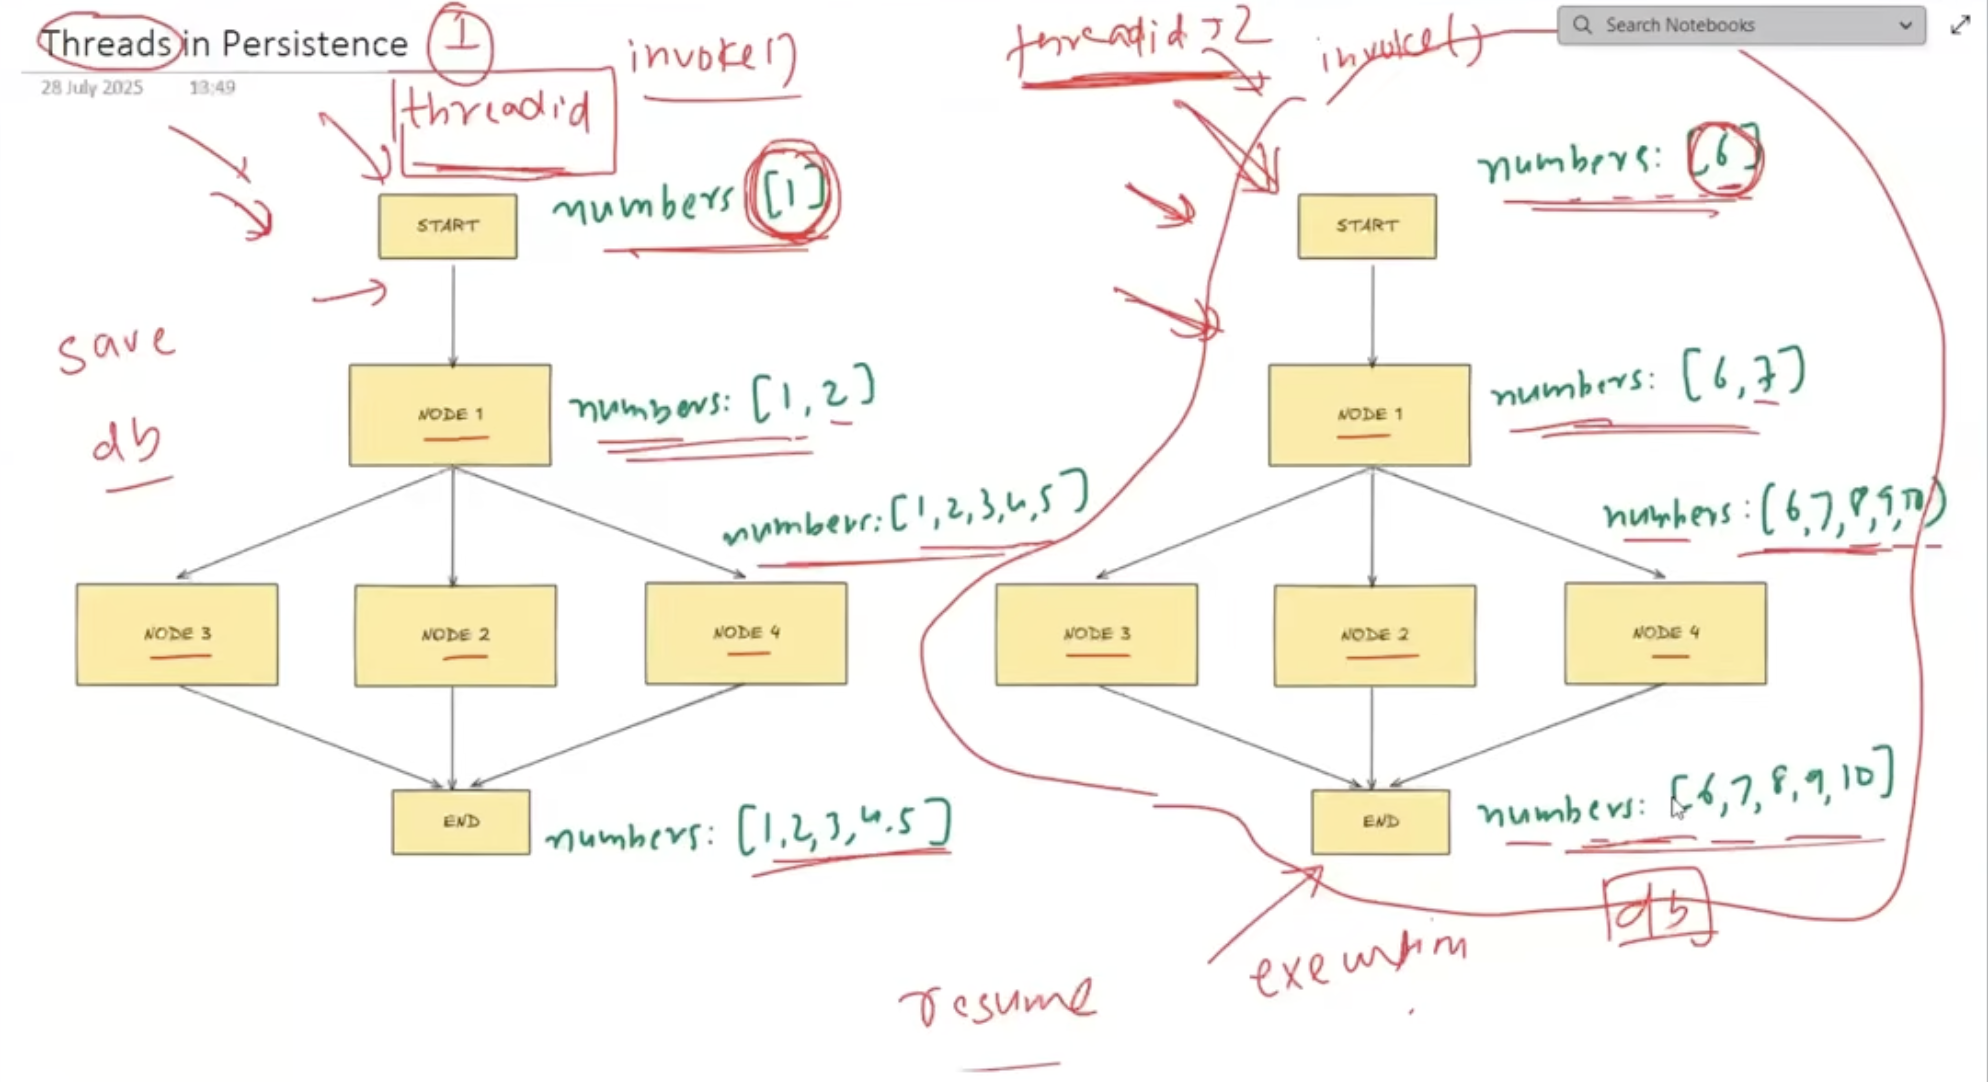

In [6]:
from langgraph.graph import StateGraph, START, END
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from typing import TypedDict, Annotated, Any, Literal
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver

In [7]:
load_dotenv()

True

In [8]:
llm = ChatOpenAI()

In [9]:
class JokeState(TypedDict):
    topic: str
    joke: str
    explanation: str

In [10]:
def generate_explanation(state: JokeState):

    prompt = f'write an explanation for the joke - {state["joke"]}'
    response = llm.invoke(prompt).content

    return {'explanation': response}

In [11]:
def generate_joke(state: JokeState):

    prompt = f'generate a joke on the topic {state["topic"]}'
    response = llm.invoke(prompt).content

    return {'joke': response}

In [12]:
graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)

In [14]:
config1 = {'configurable': {'thread_id': '1'}}
workflow.invoke({'topic': 'pizza'}, config=config1)

{'topic': 'pizza',
 'joke': "Why did the pizza go to the therapist? Because it had too many toppings and couldn't hold it all together!",
 'explanation': 'This joke plays on the double meaning of the phrase "couldn\'t hold it all together." In one sense, it could mean that the pizza physically couldn\'t hold all of its toppings together and would fall apart. In another sense, it could mean that the pizza was feeling overwhelmed or mentally unstable, and therefore needed therapy to "hold it all together." The humor comes from the unexpected idea of a pizza seeking therapy for its problems with too many toppings.'}

In [16]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': "Why did the pizza go to the therapist? Because it had too many toppings and couldn't hold it all together!", 'explanation': 'This joke plays on the double meaning of the phrase "couldn\'t hold it all together." In one sense, it could mean that the pizza physically couldn\'t hold all of its toppings together and would fall apart. In another sense, it could mean that the pizza was feeling overwhelmed or mentally unstable, and therefore needed therapy to "hold it all together." The humor comes from the unexpected idea of a pizza seeking therapy for its problems with too many toppings.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f17f78c-9c73-62b0-8002-771b47a3dd17'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-07-14T11:40:18.327370+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f17f78c-8c55-64dc-8001-d4e2704c4d18

In [ ]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': "Why did the pizza go to the therapist? Because it had too many toppings and couldn't hold it all together!", 'explanation': 'This joke plays on the double meaning of the phrase "couldn\'t hold it all together." In one sense, it could mean that the pizza physically couldn\'t hold all of its toppings together and would fall apart. In another sense, it could mean that the pizza was feeling overwhelmed or mentally unstable, and therefore needed therapy to "hold it all together." The humor comes from the unexpected idea of a pizza seeking therapy for its problems with too many toppings.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f17f78c-9c73-62b0-8002-771b47a3dd17'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-07-14T11:40:18.327370+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f17f78c-8c55-64dc-8001-d4e2704c4d1

In [18]:
config2 = {"configurable": {"thread_id" : '2'}}
workflow.invoke({'topic': 'pasta'}, config2)

{'topic': 'pasta',
 'joke': 'Why did the pasta sit on the computer? \n\nIt wanted to download some macaroni and cheese!',
 'explanation': 'This joke plays on the double meaning of the word "download." In technology, "downloading" refers to transferring data from one device, such as a computer, to another. However, in the case of the pasta sitting on the computer, it is humorously interpreted as the pasta wanting to "download" more pasta in the form of macaroni and cheese. This pun cleverly combines technology lingo with a food-related punchline to create a playful and silly joke.'}

In [19]:
workflow.get_state(config2)

StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the pasta sit on the computer? \n\nIt wanted to download some macaroni and cheese!', 'explanation': 'This joke plays on the double meaning of the word "download." In technology, "downloading" refers to transferring data from one device, such as a computer, to another. However, in the case of the pasta sitting on the computer, it is humorously interpreted as the pasta wanting to "download" more pasta in the form of macaroni and cheese. This pun cleverly combines technology lingo with a food-related punchline to create a playful and silly joke.'}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f17f796-f06d-638e-8002-a0a395578e07'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-07-14T11:44:55.568440+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f17f796-dafb-63ac-8001-a53248753b75'}}, tasks=(), interrupts=())

In [20]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': "Why did the pizza go to the therapist? Because it had too many toppings and couldn't hold it all together!", 'explanation': 'This joke plays on the double meaning of the phrase "couldn\'t hold it all together." In one sense, it could mean that the pizza physically couldn\'t hold all of its toppings together and would fall apart. In another sense, it could mean that the pizza was feeling overwhelmed or mentally unstable, and therefore needed therapy to "hold it all together." The humor comes from the unexpected idea of a pizza seeking therapy for its problems with too many toppings.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f17f78c-9c73-62b0-8002-771b47a3dd17'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-07-14T11:40:18.327370+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f17f78c-8c55-64dc-8001-d4e2704c4d18

In [22]:
list(workflow.get_state_history(config2))

[StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the pasta sit on the computer? \n\nIt wanted to download some macaroni and cheese!', 'explanation': 'This joke plays on the double meaning of the word "download." In technology, "downloading" refers to transferring data from one device, such as a computer, to another. However, in the case of the pasta sitting on the computer, it is humorously interpreted as the pasta wanting to "download" more pasta in the form of macaroni and cheese. This pun cleverly combines technology lingo with a food-related punchline to create a playful and silly joke.'}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f17f796-f06d-638e-8002-a0a395578e07'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-07-14T11:44:55.568440+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f17f796-dafb-63ac-8001-a53248753b75'}}, tasks=(), interrupts=()),
